# 1. 图像的几何变换

- 图像的几何变换在人工智能技术中是常用技术，主要应用场景用来在人工智能训练中，做图像增强处理。

- 在OpenCV中提供一组函数对图像进行几何变换处理。
    - 图像翻转：cv2.flip
    - 图像转置：cv2.transpose
    - 图像缩放：cv2.resize
    - 图像旋转：	cv.rotate
    - 图像仿射变换：cv2.warpAffine
    - 图像透视变换：cv2.warpPerspective
    - 获取旋转矩阵：cv2.getRotationMatrix2D
    - 获取仿射变换矩阵：cv2.getAffineTransform
    - 获取透视变换矩阵：cv2.getPerspectiveTransform

- 说明：
    - 使用`[]`的参数是可选参数，这是在开发文档中是通用的表达形式。

## 1.1. 图像的基本变换 

### (1) 图像翻转-flip函数

- flip翻转是以图像中心翻转，flip函数的原型定义：
    - `cv.flip(	src, flipCode[, dst]) -> dst`
        - scr参数是源图像
        - flipCode参数指定图像翻转方式，取值0，正数（一般取1），负数（一般取-1）。
            - 0 表示按照x轴翻转。
            - 正数表示按照y轴翻转。
            - 负数表示按照xy两个轴翻转。

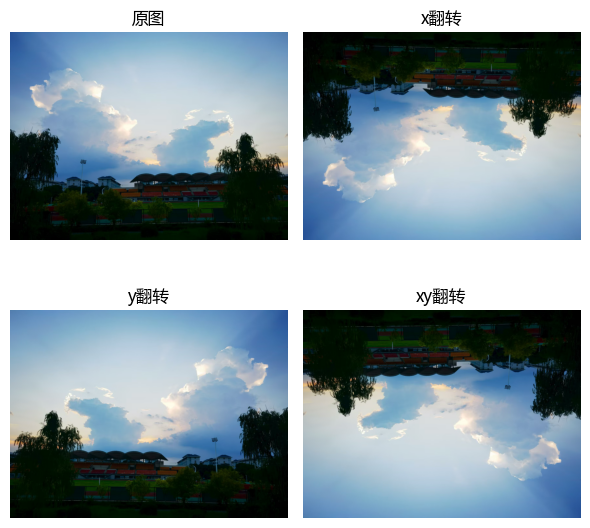

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

img_x = cv2.flip(img, 0)
img_y = cv2.flip(img, 1)
img_xy = cv2.flip(img, -1)

plt.figure(figsize=(6, 6))
plt.subplot(221)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(222)
plt.imshow(img_x)
plt.title("x翻转")
plt.axis(False)

plt.subplot(223)
plt.imshow(img_y)
plt.title("y翻转")
plt.axis(False)

plt.subplot(224)
plt.imshow(img_xy)
plt.title("xy翻转")
plt.axis(False)

plt.tight_layout()
plt.show()

### (2) 图像缩放-resize函数

- resize函数主要对图像进行放大缩小，放大缩小使用插值算法。resize函数的原型定义如下：
    - `cv.resize(src, dsize[, dst[, fx[, fy[, interpolation]]]])->dst`
        - dsize参数设置缩放后的尺寸。
        - dst参数是用参数返回缩放后图像。
        - fx,fy参数设置x与y轴方向的缩放系数。与dsize参数作用一样，两个参数二选一使用(使用fx，fy，则dsize必须设置为None)。dsize设置缩放绝对值，dx,dy设置缩放百分比。
        - interpolation参数设置插值算法，一般采用默认的就行，需要的话，可以设置如下值：
            - INTER_NEAREST：最近邻插值，取离目标点最近的像素值。
            - INTER_LINEAR：双线性插值（默认），使用周围4个像素的加权平均值。
            - INTER_CUBIC：双三次插值，使用周围16个像素的加权平均值。
            - INTER_AREA：区域插值（缩小），基于像素区域关系进行重采样。
            - INTER_LANCZOS4：Lanczos插值，使用sinc函数进行插值。
            - INTER_LINEAR_EXACT：精确双线性次插值。
            - INTER_NEAREST_EXACT：精确最近邻插值。
            - INTER_MAX：插值掩码（内部使用），不直接使用。
        - 说明：
            - 我们这里不对这些算法进行解释。

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img_src = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

img_dst1 = cv2.resize(img_src, dsize=(300, 300), interpolation=cv2.INTER_LINEAR_EXACT)
img_dst2 = cv2.resize(img_src, dsize=None, fx=0.5, fy=0.5)
print("缩放前大小：", img_src.shape)
print("缩放后大小：", img_dst1.shape)
print("缩放后大小：", img_dst2.shape)

缩放前大小： (1279, 1706, 3)
缩放后大小： (300, 300, 3)
缩放后大小： (640, 853, 3)


- 代码说明：
    - dsize参数不使用，需要设置为None，该参数必须使用。
    - dsize使用绝对值缩放，fx,fy使用相对值缩放。

### (3) 图像旋转-rotate函数

- 图像可以使用rotate函数按照图像中心进行旋转，rotate函数的原型定义如下：
    - `cv.rotate(src, rotateCode[, dst]) ->dst`
        - src参数设置需要旋转的图像。
        - rotateCode设置旋转方式，可以取值如下：
            - ROTATE_90_CLOCKWISE ：顺时针旋转90°
            - ROTATE_180 ：顺时针旋转180°
            - ROTATE_90_COUNTERCLOCKWISE ：逆时针旋转90°(等于顺时针旋转270°)

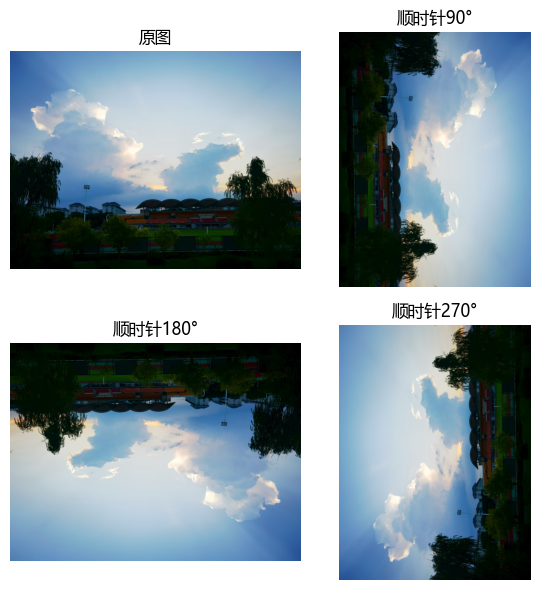

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

img1 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
img2 = cv2.rotate(img, cv2.ROTATE_180)
img3 = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)

plt.figure(figsize=(6, 6))
plt.subplot(221)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(222)
plt.imshow(img1)
plt.title("顺时针90°")
plt.axis(False)

plt.subplot(223)
plt.imshow(img2)
plt.title("顺时针180°")
plt.axis(False)

plt.subplot(224)
plt.imshow(img3)
plt.title("顺时针270°")
plt.axis(False)

plt.tight_layout()
plt.show()

- 代码说明：
    - rotate函数只有三种固定的旋转方式，更高级的旋转需要使用复杂的算法，可以旋转指定的任意角度。下面会介绍。

### (4) 图像的转置-transpose函数

- 转置操作是矩阵中的运算，用于图像就是图像转置，等于图像顺时针旋转90°。transpose函数的原型定义如下：
    - `cv.transpose(src[, dst])-> dst`

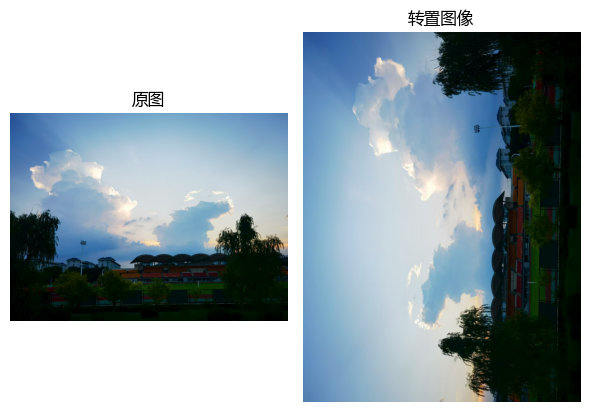

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)

img1 = cv2.transpose(img)

plt.figure(figsize=(6, 6))
plt.subplot(121)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(122)
plt.imshow(img1)
plt.title("转置图像")
plt.axis(False)

plt.tight_layout()
plt.show()

- 使用参数作为返回值的使用例子：

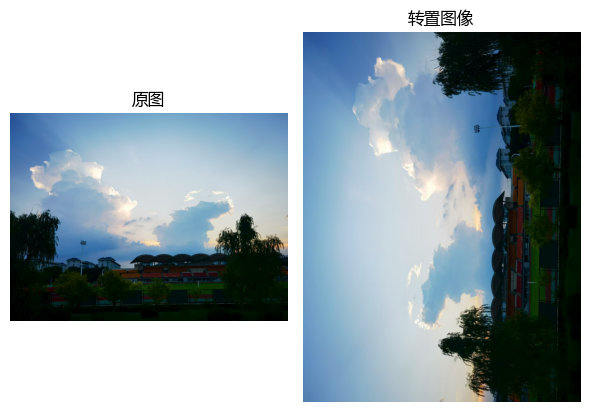

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)
h, w, c = img.shape
img1 = np.zeros(shape=(w, h, c), dtype=np.uint8)
cv2.transpose(img, img1)

plt.figure(figsize=(6, 6))
plt.subplot(121)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(122)
plt.imshow(img1)
plt.title("转置图像")
plt.axis(False)

plt.tight_layout()
plt.show()

- 代码说明：
    - 使用参数作为返回值的典型使用方式就是必须提前分配空间。而且分配空间需要满足要求。这对大部分使用者是比较麻烦的，所以在使用的时候，一般不建议使用。这种语法是来自C中的使用习惯。

## 1.2. 图像的高级变换

图像仿射变换：cv2.warpAffine
图像透视变换：cv2.warpPerspective
获取旋转矩阵：cv2.getRotationMatrix2D
获取仿射变换矩阵：cv2.getAffineTransform
获取透视变换矩阵：cv2.getPerspectiveTransform

### (1) 图像仿射变换-warpAffine

- 图像的仿射变换非常专业，需要用到较多的数学知识（几何），尤其是坐标系变换相关的解析几何的知识。尤其是需要构建变换矩阵，但是OpenCV也提供了一些比较直观的变换矩阵构建函数：
    - getRotationMatrix2D函数使用直观的方式构建旋转变换矩阵。
    - getAffineTransform函数直接构建变换矩阵，

- 仿射变换可以产生四种典型的效果：
    - 平移：translate
    - 旋转：rotate
    - 缩放：scale
    - 剪切：Shear

- warpAffine函数的原型定义与参数说明：
    - `cv.warpAffine(src, M, dsize[, dst[, flags[, borderMode[, borderValue]]]])->dst`
        - src参数：这是需要进行仿射变换的图像。
        - M参数：2×3 的变换矩阵，这个M矩阵决定了变换的类型（平移、旋转、缩放，剪切），找个矩阵的构建需要较好的数学知识。
        - dsize参数：变换后的图像尺寸 ，参数格式使用二元组(width, height)，默认是原图的大小。
        - dst参数：输出图像（可选）
        - flags参数：插值方法（默认为 INTER_LINEAR）
        - borderMode参数：边界填充模式（默认为 BORDER_CONSTANT），可取值：
            - BORDER_CONSTANT：使用常值填充边界：iiiiii|abcdefgh|iiiiiii
            - BORDER_REPLICATE：使用边界值填充：aaaaaa|abcdefgh|hhhhhhh
            - BORDER_REFLECT：使用图像数据镜像填充：fedcba|abcdefgh|hgfedcb
            - BORDER_WRAP：使用图像数据重复填充：cdefgh|abcdefgh|abcdefg
            - BORDER_REFLECT_101：使用图像数据镜像填充，但是不使用相邻的像素点：gfedcb|abcdefgh|gfedcba
            - BORDER_TRANSPARENT：透明
            - BORDER_REFLECT101： 与BORDER_REFLECT_101一样。
            - BORDER_DEFAULT：与BORDER_REFLECT_101一样
            - BORDER_ISOLATED：只对ROI区域插值
        - borderValue参数：边界填充值（默认为 0，黑色）

- 在使用warpAffine函数的最难点是构建M矩阵，但是如果理解了标准坐标系，我们就可以直接构建一个标准坐标系。
    - $\begin{bmatrix} 1&0&0\\0&1&0 \end{bmatrix}$
        - 前面两行两列控制着图像的旋转，缩放与剪切；后面两行一列控制着图像的平移。
    - 我们只看前面两行两列，每行就是一个向量。
        - 向量正交就是旋转或者缩放。不正交就是剪切。
        - 两个向量正交，向量长度为1就不缩放，不为1就是缩放，而且是随访比例。

- 仿射变换的数学公式表达如下：

```python
[x'] = [a00 a01] [x] + [b00]
[y'] = [a10 a11] [y] + [b01]
```

- M矩阵对应上面的变换公式：
```python
[a00 a01 b00]
[a10 a11 b01]
```

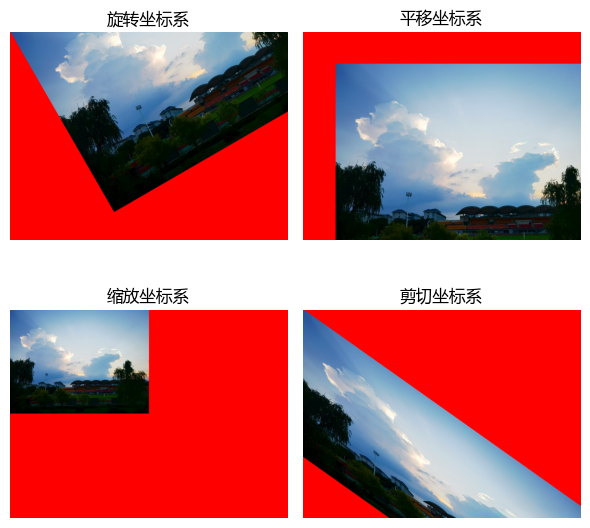

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams["font.family"] = ["Microsoft YaHei"]

img = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)
# img = img.astype(float)
# img = img / 255.0
# h, w, c = img.shape

M1 = np.array(
    [
        [1, 0, 0],
        [0, 1, 0]
    ],
    dtype=float
)

M2 = np.array(
    [
        [ math.cos(math.radians(30)), math.sin(math.radians(30)), 0],
        [-math.sin(math.radians(30)), math.cos(math.radians(30)), 0]
    ],
    dtype=float
)

M3 = np.array(
    [
        [1, 0, 200],
        [0, 1, 200]
    ],
    dtype=float
)

M4 = np.array(
    [
        [0.5, 0,   0],
        [0,   0.5, 0]
    ],
    dtype=float
)

M5 = np.array(
    [
        [1,                           0,   0],
        [math.sqrt(2)/2, math.sqrt(2)/2,   0]
    ],
    dtype=float
)


img1 = cv2.warpAffine(img, M2, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))
img2 = cv2.warpAffine(img, M3, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))
img3 = cv2.warpAffine(img, M4, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))
img4 = cv2.warpAffine(img, M5, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))

plt.figure(figsize=(6, 6))
plt.subplot(221)
plt.imshow(img1)
plt.title("旋转坐标系")
plt.axis(False)

plt.subplot(222)
plt.imshow(img2)
plt.title("平移坐标系")
plt.axis(False)

plt.subplot(223)
plt.imshow(img3)
plt.title("缩放坐标系")
plt.axis(False)

plt.subplot(224)
plt.imshow(img4)
plt.title("剪切坐标系")
plt.axis(False)

plt.tight_layout()
plt.show()

- 代码说明：
    - 关于图像的仿射变换的原理，涉及数学推理，我们可以按照图像的4中几何变换去理解坐标系的构建。
    - 最后一个变换在剪切的时候，还有缩放。
    - 在进行图像处理的时候，建议把图像转换为float类型，并且图像值使用0-1之间float值。我们上面的例子依然使用的是0-255的颜色分量。

### (2) 构建变换矩阵 - getRotationMatrix2D，getAffineTransform函数

- getRotationMatrix2D函数使用直观的参数来构建变换坐标系矩阵。
    - 旋转角度
    - 缩放比例
- getRotationMatrix2D函数的原型定义与参数说明：
    - `cv.getRotationMatrix2D(center, angle, scale)-> M`
        - center参数指定旋转中心，参数格式是二元组(float, float)，表示旋转中心坐标。
        - angle参数指定旋转角度，单位是度(°)。
        - scale参数设置缩放比例。参数格式是float，表示x与y方向使用相同的比例。

In [24]:
import cv2
import numpy as np
M = cv2.getRotationMatrix2D(center=(0, 0), angle=45, scale=1.0)
print(M)

[[ 0.70710678  0.70710678  0.        ]
 [-0.70710678  0.70710678  0.        ]]


- 更加复杂的坐标系可以使用getAffineTransform函数来构建。该函数的原型定义与参数说明如下：
    - `cv.getAffineTransform(src, dst) -> M`

- getAffineTransform使用变换前3个点与变换后3个点，构建有6个等式的方程组，通过解方程的方式得到M矩阵的6个系数。一般我们指定原点，以及两个坐标轴上点来指定src与dst。
    - 为了计算精度，要求src与dst的点都必须是float类型。

[[0.5 0.  0. ]
 [0.  0.5 0. ]]


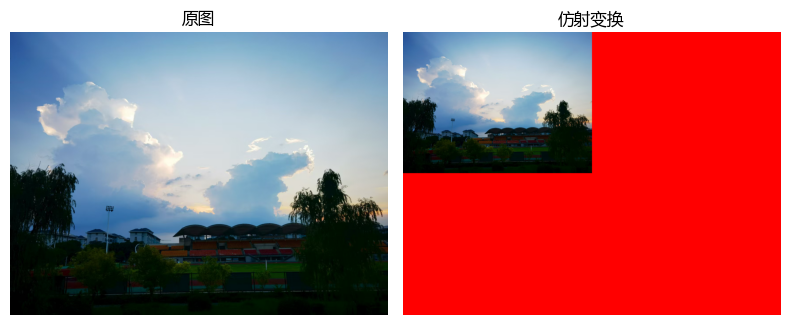

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["Microsoft YaHei"]
# 读取图像
img = cv2.imread('imgs/scene.jpg', flags=cv2.IMREAD_COLOR_RGB)

# 定义原始图像的三个点（通常为三角形顶点）
src_points = np.float32([
    [0, 0],           # 原点
    [1, 0],   # x轴上点
    [0, 1]   # y轴上点
])

# 定义变换后的三个点
dst_points = np.float32([
    [0, 0], # 原点平移
    [0.5, 0], # x轴移动50个像素
    [0, 0.5]  # x轴移动50个像素
])

# 获取仿射变换矩阵
M = cv2.getAffineTransform(src_points, dst_points)
print(M)

# 应用变换
transformed_img = cv2.warpAffine(img, M, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))

# 显示结果
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(122)
plt.imshow(transformed_img)
plt.title("仿射变换")
plt.axis(False)

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在代码中仅仅是使用平移的变换来说明。

### (3) 图像的透视图变换-warpPerspective函数与getPerspectiveTransform函数

- 透视图变换实际与仿射变换一样，只是更加灵活，功能更加强大，并且数学表达方式不同。

```txt
┌ w·x' ┐   ┌ h₁₁ h₁₂ h₁₃ ┐   ┌ x ┐
│ w·y' │ = │ h₂₁ h₂₂ h₂₃ │ · │ y │
└  w   ┘   └ h₃₁ h₃₂  1  ┘   └ 1 ┘
```

- 其中M矩阵就是：

```txt
┌ h₁₁ h₁₂ h₁₃ ┐
│ h₂₁ h₂₂ h₂₃ │
└ h₃₁ h₃₂  1  ┘
```

- 一共八个未知数，需要8个方程的方程组求解，所以计算透视图矩阵，需要8个源坐标以及8个变换后的目标坐标才能计算。

- 通常这8个点很难确定，但是使用图像的4个顶点来设置就容易了，源图像的4个点很容易确定，变换后希望得到的图像的坐标也容易得到，我们就可以轻松计算透视图矩阵。
    - 这个算法典型来自图像校正。

- getPerspectiveTransform函数的原型定义与参数说明：
    - `cv.getPerspectiveTransform(src, dst[, solveMethod]) -> retval`
        - src参数设置源图像中的四个点。
        - dst参数设置变换后目标图像中的四个点。
        - solveMethod参数设置方程组求解方法，使用线性代数求解，其中涉及求逆矩阵（求逆矩阵可能存在不可逆矩阵的情况），所以求解方法很多，可以取值：
            - cv2.DECOMP_LU：LU分解（默认）
            - cv2.DECOMP_CHOLESKY：Cholesky分解
            - cv2.DECOMP_EIG：特征值分解
            - cv2.DECOMP_SVD：奇异值分解
            - cv2.DECOMP_QR：QR分解

- warpPerspective函数的原型定义与参数说明：
    - `cv.warpPerspective(src, M, dsize[, dst[, flags[, borderMode[, borderValue]]]]) ->dst`
    - 该函数与warpAffine函数一样，我们不做赘述。

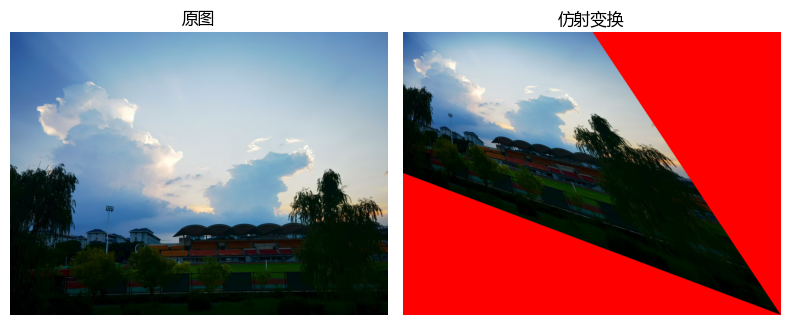

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Microsoft YaHei"]

# 读取图像
img = cv2.imread('imgs/scene.jpg', flags=cv2.IMREAD_COLOR_RGB)
h, w, c= img.shape

# 定义源点（原始图像的四个角点）
src_points = np.float32([
    [0, 0],      # 左上角
    [w, 0],     # 右上角
    [0, h],     # 左下角
    [w, h]     # 右下角
])

# 定义目标点（校正后的矩形）
dst_points = np.float32([
    [0, 0],        # 左上角(第一个点不动)
    [w/2, 0],        # 右上角
    [0, h/2],        # 左下角
    [w, h]         # 右下角（对角点不动）
])

# 计算透视变换矩阵
M = cv2.getPerspectiveTransform(src_points, dst_points)

# 应用透视变换
img_persp = cv2.warpPerspective(img, M, dsize=None, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(255.0, 0, 0))

# 显示结果
# 显示结果
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(img)
plt.title("原图")
plt.axis(False)

plt.subplot(122)
plt.imshow(img_persp)
plt.title("透视图变换")
plt.axis(False)

plt.tight_layout()

-  代码说明：
    - 仿射Affine变换使用三个点来确定变换矩阵，透视图Perspective变换使用四个点来确定变换矩阵，这是源于坐标变换的两种数学算法。
    - Perspective透视图的功能更加强大，是强烈推荐使用的方式。 

----

# 2. 图像几何变换应用实践